Dataset shape: (1000, 20)
Class balance:
 class
1    700
0    300
Name: count, dtype: int64 

===== Logistic Regression =====
              precision    recall  f1-score   support

         Bad       0.54      0.47      0.50        60
        Good       0.78      0.83      0.81       140

    accuracy                           0.72       200
   macro avg       0.66      0.65      0.65       200
weighted avg       0.71      0.72      0.71       200

===== Decision Tree =====
              precision    recall  f1-score   support

         Bad       0.45      0.37      0.40        60
        Good       0.75      0.81      0.78       140

    accuracy                           0.68       200
   macro avg       0.60      0.59      0.59       200
weighted avg       0.66      0.68      0.66       200

===== Random Forest =====
              precision    recall  f1-score   support

         Bad       0.68      0.42      0.52        60
        Good       0.79      0.91      0.84       140

    

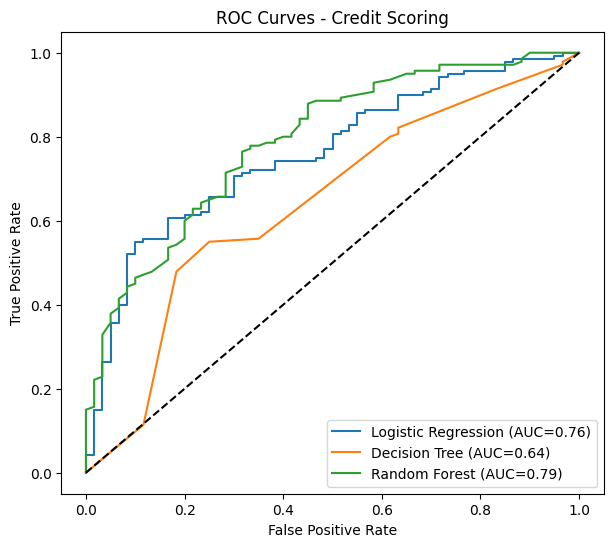


=== Model Comparison ===
              Model  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression      0.784   0.829     0.806    0.760
      Decision Tree      0.748   0.807     0.777    0.643
      Random Forest      0.785   0.914     0.845    0.790


In [1]:
# CodeAlpha_CreditScoringModel
# Task 1: Credit Scoring Model
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, classification_report)


data = fetch_openml("credit-g", version=1, as_frame=True)
X = data.data.copy()
y = (data.target == "good").astype(int)
print("Dataset shape:", X.shape)
print("Class balance:\n", y.value_counts(), "\n")


X["credit_per_month"] = X["credit_amount"] / X["duration"]
X["credit_to_age"] = X["credit_amount"] / X["age"]
X["installment_burden"] = X["installment_commitment"] * X["credit_per_month"]

num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

pre = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
}

results = []
plt.figure(figsize=(7, 6))
for name, clf in models.items():
    pipe = Pipeline([("pre", pre), ("clf", clf)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    prob = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1-Score": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, prob),
    })
    print(f"===== {name} =====")
    print(classification_report(y_test, pred, target_names=["Bad", "Good"]))

    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, prob):.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Credit Scoring")
plt.legend()
plt.savefig("roc_curves.png", dpi=150)
plt.show()

print("\n=== Model Comparison ===")
print(pd.DataFrame(results).round(3).to_string(index=False))


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28, 1) Test: (10000, 28, 28, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
422/422 - 45s - 107ms/step - accuracy: 0.9196 - loss: 0.2651 - val_accuracy: 0.9842 - val_loss: 0.0614
Epoch 2/8
422/422 - 44s - 105ms/step - accuracy: 0.9734 - loss: 0.0840 - val_accuracy: 0.9898 - val_loss: 0.0391
Epoch 3/8
422/422 - 81s - 191ms/step - accuracy: 0.9802 - loss: 0.0625 - val_accuracy: 0.9903 - val_loss: 0.0331
Epoch 4/8
422/422 - 43s - 102ms/step - accuracy: 0.9843 - loss: 0.0486 - val_accuracy: 0.9912 - val_loss: 0.0316
Epoch 5/8
422/422 - 42s - 100ms/step - accuracy: 0.9868 - loss: 0.0417 - val_accuracy: 0.9918 - val_loss: 0.0290
Epoch 6/8
422/422 - 82s - 193ms/step - accuracy: 0.9886 - loss: 0.0356 - val_accuracy: 0.9925 - val_loss: 0.0268
Epoch 7/8
422/422 - 42s - 99ms/step - accuracy: 0.9890 - loss: 0.0338 - val_accuracy: 0.9915 - val_loss: 0.0293
Epoch 8/8
422/422 - 82s - 194ms/step - accuracy: 0.9901 - loss: 0.0304 - val_accuracy: 0.9928 - val_loss: 0.0258

Test Accuracy: 99.28%

Classification Report:
               precision    recall  f1-score   sup

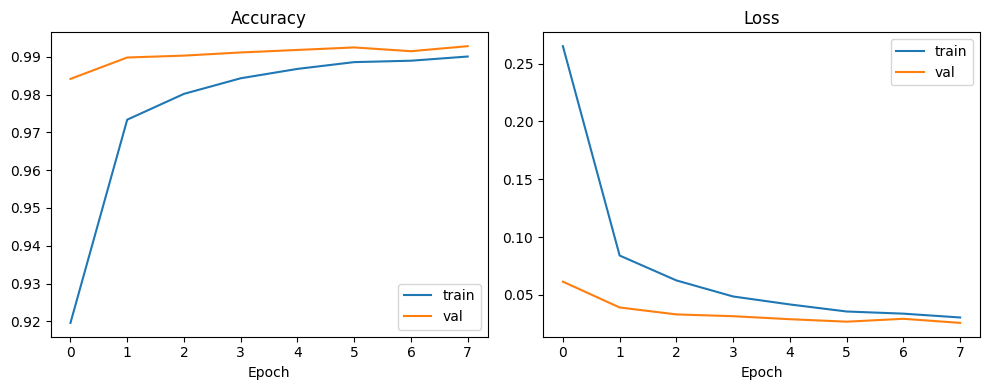

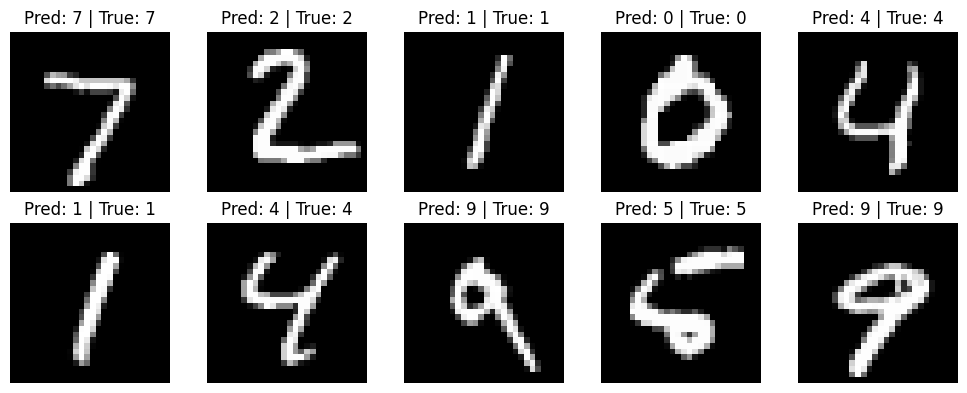

Model saved as mnist_cnn_model.keras


In [2]:
# CodeAlpha_HandwrittenCharacterRecognition
# Task 3: Handwritten Character Recognition (MNIST + CNN)
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix


(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train[..., None].astype("float32") / 255.0
x_test = x_test[..., None].astype("float32") / 255.0
print("Train:", x_train.shape, "Test:", x_test.shape)


model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"),
])
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()


history = model.fit(x_train, y_train, epochs=8, batch_size=128,
                    validation_split=0.1, verbose=2)


loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Accuracy: {acc * 100:.2f}%")

y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy"); plt.xlabel("Epoch"); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss"); plt.xlabel("Epoch"); plt.legend()
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()


plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.title(f"Pred: {y_pred[i]} | True: {y_test[i]}")
    plt.axis("off")
plt.tight_layout()
plt.savefig("sample_predictions.png", dpi=150)
plt.show()


model.save("mnist_cnn_model.keras")
print("Model saved as mnist_cnn_model.keras")